# 2f. Modelagem estatística da transição de R1 para R2

Este notebook será utilizado para construir uma leitura estatística da transição de R1 para R2, com foco em duas perguntas centrais: quais características estão associadas ao avanço para R2 e em que ritmo esse avanço costuma acontecer.

A proposta é complementar a análise operacional já realizada com uma abordagem mais explicativa e preditiva, capaz de apoiar a priorização comercial. Para isso, será usada a regressão logística como modelo principal de propensão ao sucesso em R1 → R2, acompanhada por uma leitura de tempo até o avanço com Kaplan-Meier.

A avaliação do modelo não ficará presa ao ponto de corte padrão de 0,5. O desempenho será analisado com ênfase na relação entre precisão e recall, buscando uma leitura mais útil para separar os negócios com maior probabilidade de chegar a R2 e apoiar decisões práticas do comercial.

In [ ]:
# ==========================================================
# 1. PREPARAÇÃO DO AMBIENTE E CARREGAMENTO DA BASE ANALÍTICA
# ==========================================================

import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    precision_recall_curve,
    average_precision_score,
    confusion_matrix,
)

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", 200)
pd.set_option("display.max_rows", 200)
pd.set_option("display.width", 180)

plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["axes.titlesize"] = 13
plt.rcParams["axes.labelsize"] = 11
plt.rcParams["xtick.labelsize"] = 10
plt.rcParams["ytick.labelsize"] = 10

caminho_abt_funil = Path(
    "/kaggle/input/notebooks/glauciojfrosa/2a-construcao-abt-funil/outputs_abt_funil/abt_funil_v1.parquet"
)

abt_funil = pd.read_parquet(caminho_abt_funil)

print("Base analítica do funil carregada com sucesso.")
print(f"Caminho utilizado: {caminho_abt_funil}")
print(f"Dimensão da base: {abt_funil.shape[0]:,} linhas x {abt_funil.shape[1]:,} colunas".replace(",", "."))

Base analítica do funil carregada com sucesso.
Caminho utilizado: /kaggle/input/notebooks/glauciojfrosa/2a-construcao-abt-funil/outputs_abt_funil/abt_funil_v1.parquet
Dimensão da base: 128.016 linhas x 64 colunas


A base foi carregada com sucesso e o ambiente já está pronto para a modelagem estatística da transição de R1 para R2. A partir desse ponto, passa a ser possível separar os negócios que avançam dos que não avançam e avaliar se existem sinais capazes de apoiar uma priorização comercial mais orientada por probabilidade de sucesso.

## 2. Inspeção inicial das variáveis candidatas à modelagem

Será feita uma conferência inicial das colunas disponíveis para identificar quais variáveis podem entrar na modelagem sem comprometer a coerência temporal da análise, preservando apenas sinais que façam sentido para explicar o avanço de R1 para R2.

In [ ]:
# ==========================================================
# 2. INSPEÇÃO INICIAL DAS VARIÁVEIS CANDIDATAS À MODELAGEM
# ==========================================================

colunas_abt = abt_funil.columns.tolist()

palavras_chave_relevantes = [
    "r1",
    "r2",
    "proposta",
    "assinatura",
    "atividade",
    "tempo",
    "data",
    "dias",
    "quantidade",
    "origem",
    "canal",
    "responsavel",
    "owner",
    "valor",
    "negocio",
    "etapa",
    "contato",
    "pipeline",
    "status",
]

colunas_candidatas_modelagem = sorted([
    coluna
    for coluna in colunas_abt
    if any(palavra in coluna.lower() for palavra in palavras_chave_relevantes)
])

resumo_inspecao_variaveis_modelagem = pd.DataFrame({
    "quantidade_total_colunas_abt": [len(colunas_abt)],
    "quantidade_colunas_candidatas_modelagem": [len(colunas_candidatas_modelagem)],
})

display(resumo_inspecao_variaveis_modelagem)

print("\nPrimeiras colunas candidatas encontradas:")
for coluna in colunas_candidatas_modelagem[:120]:
    print(coluna)

if len(colunas_candidatas_modelagem) > 120:
    print(f"\nForam listadas 120 de {len(colunas_candidatas_modelagem)} colunas candidatas.")

print("\nCódigo executado com sucesso.")

,quantidade_total_colunas_abt,quantidade_colunas_candidatas_modelagem
0,64,43



Primeiras colunas candidatas encontradas:
chegou_em_proposta
chegou_em_r1
chegou_em_r2
data_primeira_passagem_concluido
data_primeira_passagem_contato_efetivo
data_primeira_passagem_enviar_proposta
data_primeira_passagem_execucao_operacional
data_primeira_passagem_negociando
data_primeira_passagem_oportunidade
data_primeira_passagem_primeira_parcela
data_primeira_passagem_r1
data_primeira_passagem_r2
data_primeira_passagem_subir_assinatura
data_primeira_passagem_tentativa_contato
data_ultima_atividade
dias_desde_ultima_atividade
esta_parado_14_dias
esta_parado_30_dias
esta_parado_7_dias
maior_ordem_etapa_alcancada
nome_etapa_atual
nome_maior_etapa_alcancada
nome_negocio
nome_pipeline
ordem_etapa_atual
origem_lead
pipeline_id
quantidade_atividades_total
responsavel_negocio
status_negocio
tempo_ate_concluido_dias
tempo_ate_contato_efetivo_dias
tempo_ate_enviar_proposta_dias
tempo_ate_execucao_operacional_dias
tempo_ate_negociando_dias
tempo_ate_oportunidade_dias
tempo_ate_primeira_parce

A base traz um conjunto relevante de variáveis candidatas à modelagem, com 43 colunas inicialmente relacionadas ao avanço no funil, atividade recente, tempo de percurso, estágio atual e atributos operacionais do negócio. Isso indica que há material suficiente para construir um modelo explicativo, desde que seja feita uma triagem cuidadosa para separar os sinais úteis das variáveis que poderiam introduzir vazamento de informação.

O principal cuidado agora está em excluir tudo o que só passa a existir depois de R1 ou depois de R2, como tempos e datas de etapas futuras. Para o comercial, isso é decisivo: a proposta não é criar um modelo artificialmente forte, mas uma leitura confiável sobre quais sinais já disponíveis no momento de R1 ajudam a identificar maior ou menor chance de avanço para R2.

## 3. Construção da base analítica da modelagem

Será definido o universo da modelagem e será feita a primeira seleção das variáveis elegíveis, preservando apenas os negócios que chegaram a R1 e removendo sinais que representem informação posterior ao momento em que a decisão comercial ainda precisa ser tomada.

In [ ]:
# ==========================================================
# 3. CONSTRUÇÃO DA BASE ANALÍTICA DA MODELAGEM
# ==========================================================

base_modelagem_r1_r2 = abt_funil.copy()

for coluna_data in [
    "data_primeira_passagem_r1",
    "data_primeira_passagem_r2",
    "data_ultima_atividade",
]:
    if coluna_data in base_modelagem_r1_r2.columns:
        base_modelagem_r1_r2[coluna_data] = pd.to_datetime(
            base_modelagem_r1_r2[coluna_data],
            errors="coerce"
        )

base_modelagem_r1_r2 = base_modelagem_r1_r2.loc[
    base_modelagem_r1_r2["chegou_em_r1"].fillna(False)
].copy()

colunas_excluir_vazamento = [
    "chegou_em_r2",
    "chegou_em_proposta",
    "data_primeira_passagem_r2",
    "data_primeira_passagem_enviar_proposta",
    "data_primeira_passagem_negociando",
    "data_primeira_passagem_subir_assinatura",
    "data_primeira_passagem_primeira_parcela",
    "data_primeira_passagem_execucao_operacional",
    "data_primeira_passagem_concluido",
    "tempo_ate_r2_dias",
    "tempo_ate_enviar_proposta_dias",
    "tempo_ate_negociando_dias",
    "tempo_ate_subir_assinatura_dias",
    "tempo_ate_primeira_parcela_dias",
    "tempo_ate_execucao_operacional_dias",
    "tempo_ate_concluido_dias",
    "nome_etapa_atual",
    "ordem_etapa_atual",
    "nome_maior_etapa_alcancada",
    "maior_ordem_etapa_alcancada",
]

colunas_base_inicial_modelagem = [
    "deal_id",
    "nome_negocio",
    "nome_pipeline",
    "pipeline_id",
    "status_negocio",
    "origem_lead",
    "responsavel_negocio",
    "quantidade_atividades_total",
    "data_ultima_atividade",
    "dias_desde_ultima_atividade",
    "teve_atividade_ultimos_7_dias",
    "teve_atividade_ultimos_14_dias",
    "teve_atividade_ultimos_30_dias",
    "esta_parado_7_dias",
    "esta_parado_14_dias",
    "esta_parado_30_dias",
    "data_primeira_passagem_tentativa_contato",
    "data_primeira_passagem_contato_efetivo",
    "data_primeira_passagem_oportunidade",
    "data_primeira_passagem_r1",
    "tempo_ate_contato_efetivo_dias",
    "tempo_ate_oportunidade_dias",
    "tempo_ate_r1_dias",
]

colunas_base_inicial_modelagem = [
    coluna for coluna in colunas_base_inicial_modelagem
    if coluna in base_modelagem_r1_r2.columns
]

base_modelagem_r1_r2 = base_modelagem_r1_r2[colunas_base_inicial_modelagem + ["chegou_em_r2"]].copy()

resumo_base_modelagem_r1_r2 = pd.DataFrame({
    "indicador": [
        "Negócios que chegaram em R1",
        "Colunas mantidas para modelagem inicial",
        "Colunas excluídas por potencial vazamento",
    ],
    "valor": [
        len(base_modelagem_r1_r2),
        len(colunas_base_inicial_modelagem),
        len([col for col in colunas_excluir_vazamento if col in abt_funil.columns]),
    ]
})

display(resumo_base_modelagem_r1_r2)

print("\nColunas mantidas para modelagem inicial:")
for coluna in colunas_base_inicial_modelagem:
    print(coluna)

print("\nCódigo executado com sucesso.")

,indicador,valor
0,Negócios que chegaram em R1,8358
1,Colunas mantidas para modelagem inicial,23
2,Colunas excluídas por potencial vazamento,20



Colunas mantidas para modelagem inicial:
deal_id
nome_negocio
nome_pipeline
pipeline_id
status_negocio
origem_lead
responsavel_negocio
quantidade_atividades_total
data_ultima_atividade
dias_desde_ultima_atividade
teve_atividade_ultimos_7_dias
teve_atividade_ultimos_14_dias
teve_atividade_ultimos_30_dias
esta_parado_7_dias
esta_parado_14_dias
esta_parado_30_dias
data_primeira_passagem_tentativa_contato
data_primeira_passagem_contato_efetivo
data_primeira_passagem_oportunidade
data_primeira_passagem_r1
tempo_ate_contato_efetivo_dias
tempo_ate_oportunidade_dias
tempo_ate_r1_dias

Código executado com sucesso.


A base de modelagem ficou com 8.358 negócios que chegaram a R1 e com 23 variáveis iniciais potencialmente úteis para explicar o avanço até R2. Ao mesmo tempo, 20 colunas foram retiradas por representarem informação posterior ao ponto em que o comercial ainda precisa decidir como agir.

Na prática, isso deixa a modelagem mais confiável. Em vez de produzir um resultado artificialmente forte, a análise passa a trabalhar com sinais que já existiam quando o negócio estava em R1, o que torna a probabilidade estimada muito mais útil para priorização comercial real.

## 4. Definição do alvo binário de sucesso em R1 para R2

Será criado o desfecho da modelagem para distinguir, entre os negócios que chegaram a R1, quais avançaram para R2 e quais permaneceram sem esse avanço.

In [ ]:
# ==========================================================
# 4. DEFINIÇÃO DO ALVO BINÁRIO DE SUCESSO EM R1 PARA R2
# ==========================================================

base_modelagem_r1_r2["sucesso_r1_r2"] = (
    abt_funil.loc[base_modelagem_r1_r2.index, "chegou_em_r2"]
    .fillna(False)
    .astype(int)
)

resumo_alvo_modelagem = (
    base_modelagem_r1_r2["sucesso_r1_r2"]
    .value_counts(dropna=False)
    .sort_index()
    .rename_axis("sucesso_r1_r2")
    .reset_index(name="quantidade_negocios")
)

resumo_alvo_modelagem["classe"] = resumo_alvo_modelagem["sucesso_r1_r2"].map({
    0: "Não avançou para R2",
    1: "Avançou para R2",
})

resumo_alvo_modelagem["percentual"] = (
    resumo_alvo_modelagem["quantidade_negocios"]
    / resumo_alvo_modelagem["quantidade_negocios"].sum()
    * 100
).round(2)

display(
    resumo_alvo_modelagem[
        ["classe", "quantidade_negocios", "percentual"]
    ]
)

print("\nCódigo executado com sucesso.")

,classe,quantidade_negocios,percentual
0,Não avançou para R2,2854,34.15
1,Avançou para R2,5504,65.85



Código executado com sucesso.


A variável-alvo ficou bem distribuída para a modelagem, com 65,85% dos negócios classificados como avanço para R2 e 34,15% como não avanço. Isso indica que há volume suficiente nas duas classes para sustentar uma leitura estatística útil, sem depender de um cenário extremo de desequilíbrio.

Para o comercial, isso é positivo porque aumenta a chance de o modelo conseguir distinguir perfis com maior e menor probabilidade de avanço de forma mais estável. Na prática, a base oferece uma boa condição para separar os casos que tendem a seguir adiante daqueles que merecem maior atenção para não perder tração após R1.

In [ ]:
# ==========================================================
# 5. ANÁLISE EXPLORATÓRIA INICIAL DAS VARIÁVEIS EXPLICATIVAS
# ==========================================================

variaveis_numericas_candidatas = [
    "quantidade_atividades_total",
    "dias_desde_ultima_atividade",
    "tempo_ate_contato_efetivo_dias",
    "tempo_ate_oportunidade_dias",
    "tempo_ate_r1_dias",
]

variaveis_categoricas_candidatas = [
    "nome_pipeline",
    "status_negocio",
    "origem_lead",
    "responsavel_negocio",
    "teve_atividade_ultimos_7_dias",
    "teve_atividade_ultimos_14_dias",
    "teve_atividade_ultimos_30_dias",
    "esta_parado_7_dias",
    "esta_parado_14_dias",
    "esta_parado_30_dias",
]

variaveis_numericas_candidatas = [
    coluna for coluna in variaveis_numericas_candidatas
    if coluna in base_modelagem_r1_r2.columns
]

variaveis_categoricas_candidatas = [
    coluna for coluna in variaveis_categoricas_candidatas
    if coluna in base_modelagem_r1_r2.columns
]

resumo_variaveis_numericas = (
    base_modelagem_r1_r2[variaveis_numericas_candidatas]
    .describe()
    .T
    .reset_index()
    .rename(columns={"index": "variavel"})
)

resumo_faltantes = pd.DataFrame({
    "variavel": variaveis_numericas_candidatas + variaveis_categoricas_candidatas,
    "quantidade_faltantes": [
        int(base_modelagem_r1_r2[coluna].isna().sum())
        for coluna in variaveis_numericas_candidatas + variaveis_categoricas_candidatas
    ],
})

resumo_faltantes["percentual_faltantes"] = (
    resumo_faltantes["quantidade_faltantes"] / len(base_modelagem_r1_r2) * 100
).round(2)

display(resumo_variaveis_numericas)

display(
    resumo_faltantes.sort_values(
        ["percentual_faltantes", "variavel"],
        ascending=[False, True]
    ).reset_index(drop=True)
)

print("\nCódigo executado com sucesso.")

,variavel,count,mean,std,min,25%,50%,75%,max
0,quantidade_atividades_total,8357.0,33.042958,20.216053,1.0,19.0,28.0,41.0,178.0
1,dias_desde_ultima_atividade,8357.0,141.443939,79.039069,19.0,66.0,134.0,205.0,346.0
2,tempo_ate_contato_efetivo_dias,2292.0,3.823735,10.548402,-141.0,0.0,0.0,5.0,147.0
3,tempo_ate_oportunidade_dias,4114.0,0.783179,11.602005,-47.0,0.0,0.0,0.0,162.0
4,tempo_ate_r1_dias,4153.0,7.355165,14.618883,-141.0,0.0,3.0,8.0,205.0


,variavel,quantidade_faltantes,percentual_faltantes
0,tempo_ate_contato_efetivo_dias,6066,72.58
1,tempo_ate_oportunidade_dias,4244,50.78
2,tempo_ate_r1_dias,4205,50.31
3,dias_desde_ultima_atividade,1,0.01
4,esta_parado_14_dias,1,0.01
5,esta_parado_30_dias,1,0.01
6,esta_parado_7_dias,1,0.01
7,quantidade_atividades_total,1,0.01
8,teve_atividade_ultimos_14_dias,1,0.01
9,teve_atividade_ultimos_30_dias,1,0.01



Código executado com sucesso.


A leitura inicial mostra que a base traz sinais promissores para a modelagem, mas também alguns pontos que exigem cuidado antes do ajuste do modelo. Variáveis como quantidade total de atividades, dias desde a última atividade, status, origem do lead e responsável do negócio aparecem praticamente completas, o que é positivo para sustentar uma leitura mais estável sobre a chance de avanço para R2.

Em contrapartida, os tempos até contato efetivo, oportunidade e R1 apresentam muitos faltantes e ainda trazem valores negativos, o que indica possível inconsistência de registro ou diferença entre marcos operacionais e datas capturadas na base. Para o comercial, a leitura prática é que já existem bons sinais para começar a modelagem, mas parte das variáveis de tempo precisa ser tratada com cautela para não introduzir ruído em vez de melhorar a capacidade de separação entre casos com maior e menor probabilidade de avanço.

## 6. Tratamento inicial das variáveis para a modelagem

Serão feitos os primeiros ajustes nas variáveis explicativas para reduzir ruído, tratar inconsistências evidentes e preparar a base para uma modelagem mais estável e mais fiel à realidade operacional.

In [ ]:
# ==========================================================
# 6. TRATAMENTO INICIAL DAS VARIÁVEIS PARA A MODELAGEM
# ==========================================================

base_modelagem_tratada = base_modelagem_r1_r2.copy()

variaveis_tempo_para_tratar = [
    "tempo_ate_contato_efetivo_dias",
    "tempo_ate_oportunidade_dias",
    "tempo_ate_r1_dias",
]

for coluna in variaveis_tempo_para_tratar:
    if coluna in base_modelagem_tratada.columns:
        base_modelagem_tratada[coluna] = pd.to_numeric(
            base_modelagem_tratada[coluna],
            errors="coerce"
        )
        base_modelagem_tratada.loc[
            base_modelagem_tratada[coluna] < 0,
            coluna
        ] = np.nan

variaveis_booleanas = [
    "teve_atividade_ultimos_7_dias",
    "teve_atividade_ultimos_14_dias",
    "teve_atividade_ultimos_30_dias",
    "esta_parado_7_dias",
    "esta_parado_14_dias",
    "esta_parado_30_dias",
]

for coluna in variaveis_booleanas:
    if coluna in base_modelagem_tratada.columns:
        base_modelagem_tratada[coluna] = (
            base_modelagem_tratada[coluna]
            .fillna(False)
            .astype(str)
        )

if "quantidade_atividades_total" in base_modelagem_tratada.columns:
    base_modelagem_tratada["quantidade_atividades_total"] = pd.to_numeric(
        base_modelagem_tratada["quantidade_atividades_total"],
        errors="coerce"
    )

if "dias_desde_ultima_atividade" in base_modelagem_tratada.columns:
    base_modelagem_tratada["dias_desde_ultima_atividade"] = pd.to_numeric(
        base_modelagem_tratada["dias_desde_ultima_atividade"],
        errors="coerce"
    )

quantidade_negativos_contato = (
    int(((base_modelagem_r1_r2["tempo_ate_contato_efetivo_dias"] < 0).fillna(False)).sum())
    if "tempo_ate_contato_efetivo_dias" in base_modelagem_r1_r2.columns else 0
)

quantidade_negativos_oportunidade = (
    int(((base_modelagem_r1_r2["tempo_ate_oportunidade_dias"] < 0).fillna(False)).sum())
    if "tempo_ate_oportunidade_dias" in base_modelagem_r1_r2.columns else 0
)

quantidade_negativos_r1 = (
    int(((base_modelagem_r1_r2["tempo_ate_r1_dias"] < 0).fillna(False)).sum())
    if "tempo_ate_r1_dias" in base_modelagem_r1_r2.columns else 0
)

resumo_tratamento_inicial = pd.DataFrame({
    "indicador": [
        "Negativos substituídos por ausente em tempo até contato efetivo",
        "Negativos substituídos por ausente em tempo até oportunidade",
        "Negativos substituídos por ausente em tempo até R1",
    ],
    "valor": [
        quantidade_negativos_contato,
        quantidade_negativos_oportunidade,
        quantidade_negativos_r1,
    ]
})

print("=" * 90)
print("TRATAMENTO DE VALORES NEGATIVOS NAS VARIÁVEIS DE TEMPO")
print(f"Tempo até contato efetivo: {quantidade_negativos_contato}")
print(f"Tempo até oportunidade: {quantidade_negativos_oportunidade}")
print(f"Tempo até R1: {quantidade_negativos_r1}")
print("\nCódigo executado com sucesso.")

TRATAMENTO DE VALORES NEGATIVOS NAS VARIÁVEIS DE TEMPO
Tempo até contato efetivo: 19
Tempo até oportunidade: 43
Tempo até R1: 20

Código executado com sucesso.


Os valores negativos encontrados nas variáveis de tempo foram tratados como ausentes, por indicarem inconsistência de registro e não uma duração válida do processo. Esse ajuste atingiu 19 casos em tempo até contato efetivo, 43 em tempo até oportunidade e 20 em tempo até R1.

Além disso, as variáveis booleanas de atividade recente e de parada foram padronizadas, e as variáveis numéricas centrais foram convertidas para formato adequado de modelagem. Na prática, isso reduz o risco de o modelo aprender padrões artificiais a partir de erros do dado e aumenta a chance de a probabilidade estimada refletir sinais operacionais mais próximos da realidade da carteira.

## 7. Separação entre treino e teste da base de modelagem

A base será dividida entre amostras de treino e de teste para permitir uma avaliação mais confiável do desempenho da regressão, separando o ajuste do modelo da etapa em que sua capacidade de generalização será verificada.

In [ ]:
# ==========================================================
# 7. SEPARAÇÃO ENTRE TREINO E TESTE DA BASE DE MODELAGEM
# ==========================================================

coluna_alvo = "sucesso_r1_r2"

colunas_identificacao = [
    "deal_id",
    "nome_negocio",
    "data_ultima_atividade",
    "data_primeira_passagem_tentativa_contato",
    "data_primeira_passagem_contato_efetivo",
    "data_primeira_passagem_oportunidade",
    "data_primeira_passagem_r1",
]

colunas_identificacao_presentes = [
    coluna for coluna in colunas_identificacao
    if coluna in base_modelagem_tratada.columns
]

variaveis_modelagem = [
    coluna for coluna in base_modelagem_tratada.columns
    if coluna not in colunas_identificacao_presentes + [coluna_alvo]
]

X = base_modelagem_tratada[variaveis_modelagem].copy()
y = base_modelagem_tratada[coluna_alvo].copy()

X_treino, X_teste, y_treino, y_teste = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

resumo_divisao_treino_teste = pd.DataFrame({
    "conjunto": ["Treino", "Teste", "Total"],
    "quantidade_registros": [
        len(X_treino),
        len(X_teste),
        len(X),
    ],
    "percentual_sucesso_r1_r2": [
        round(y_treino.mean() * 100, 2),
        round(y_teste.mean() * 100, 2),
        round(y.mean() * 100, 2),
    ]
})

display(resumo_divisao_treino_teste)

print("\nCódigo executado com sucesso.")

,conjunto,quantidade_registros,percentual_sucesso_r1_r2
0,Treino,6686,65.85
1,Teste,1672,65.85
2,Total,8358,65.85



Código executado com sucesso.


A divisão entre treino e teste ficou equilibrada, com 6.686 registros no treino e 1.672 no teste, preservando exatamente a mesma proporção de sucesso observada na base total. Isso é positivo porque mantém a etapa de avaliação alinhada ao comportamento real do conjunto analisado.

Na prática, essa configuração favorece o ajuste do modelo ao ampliar a amostra de treino, sem perder a capacidade de testar o desempenho fora da amostra. Para o comercial, isso ajuda a dar mais confiança de que a probabilidade estimada foi construída com base robusta e ainda assim será validada em um grupo separado de negócios com perfil semelhante ao universo real.

## 8. Ajuste da regressão logística como modelo principal

Será ajustada a regressão logística para estimar a probabilidade de avanço de R1 para R2 a partir dos sinais disponíveis até R1, buscando identificar quais características ajudam a separar os negócios com maior e menor chance de sucesso.

In [ ]:
# ==========================================================
# 8. AJUSTE DA REGRESSÃO LOGÍSTICA COMO MODELO PRINCIPAL
# ==========================================================

variaveis_numericas_modelo = [
    "quantidade_atividades_total",
    "dias_desde_ultima_atividade",
    "tempo_ate_contato_efetivo_dias",
    "tempo_ate_oportunidade_dias",
    "tempo_ate_r1_dias",
]

variaveis_categoricas_modelo = [
    "nome_pipeline",
    "status_negocio",
    "origem_lead",
    "responsavel_negocio",
    "teve_atividade_ultimos_7_dias",
    "teve_atividade_ultimos_14_dias",
    "teve_atividade_ultimos_30_dias",
    "esta_parado_7_dias",
    "esta_parado_14_dias",
    "esta_parado_30_dias",
]

variaveis_numericas_modelo = [
    coluna for coluna in variaveis_numericas_modelo
    if coluna in X_treino.columns
]

variaveis_categoricas_modelo = [
    coluna for coluna in variaveis_categoricas_modelo
    if coluna in X_treino.columns
]

preprocessador_regressao = ColumnTransformer(
    transformers=[
        (
            "numericas",
            Pipeline(steps=[
                ("imputar", SimpleImputer(strategy="median")),
            ]),
            variaveis_numericas_modelo,
        ),
        (
            "categoricas",
            Pipeline(steps=[
                ("imputar", SimpleImputer(strategy="most_frequent")),
                ("onehot", OneHotEncoder(handle_unknown="ignore")),
            ]),
            variaveis_categoricas_modelo,
        ),
    ],
    remainder="drop",
)

modelo_regressao_logistica = Pipeline(steps=[
    ("preprocessamento", preprocessador_regressao),
    ("modelo", LogisticRegression(max_iter=2000, random_state=42)),
])

modelo_regressao_logistica.fit(X_treino, y_treino)

probabilidades_teste_regressao = modelo_regressao_logistica.predict_proba(X_teste)[:, 1]
predicoes_teste_regressao_05 = (probabilidades_teste_regressao >= 0.50).astype(int)

resumo_ajuste_regressao = pd.DataFrame({
    "indicador": [
        "Quantidade de variáveis numéricas utilizadas",
        "Quantidade de variáveis categóricas utilizadas",
        "Quantidade de registros no treino",
        "Quantidade de registros no teste",
        "Probabilidade média prevista no teste",
    ],
    "valor": [
        len(variaveis_numericas_modelo),
        len(variaveis_categoricas_modelo),
        len(X_treino),
        len(X_teste),
        round(probabilidades_teste_regressao.mean(), 4),
    ]
})

display(resumo_ajuste_regressao)

print("\nCódigo executado com sucesso.")

,indicador,valor
0,Quantidade de variáveis numéricas utilizadas,5.0000
1,Quantidade de variáveis categóricas utilizadas,10.0000
2,Quantidade de registros no treino,6686.0000
3,Quantidade de registros no teste,1672.0000
4,Probabilidade média prevista no teste,0.6611



Código executado com sucesso.


A regressão logística foi ajustada com 15 variáveis explicativas, sendo 5 numéricas e 10 categóricas, usando 6.686 registros para treino e 1.672 para teste. No conjunto de teste, a probabilidade média prevista pelo modelo ficou em 66,11%, enquanto a taxa real de avanço de R1 para R2 nesse mesmo conjunto foi de 65,85%.

Isso significa que, em média, o modelo estimou uma chance de sucesso muito próxima do que de fato ocorreu na base. Em termos práticos, a calibragem inicial ficou boa: o modelo não passou a impressão de que a carteira teria chance muito maior ou muito menor de avanço do que a observada na realidade. Para o comercial, isso é importante porque mostra que a régua de probabilidade começa alinhada ao comportamento real dos negócios, criando uma base mais confiável para diferenciar casos com maior e menor chance de chegar a R2.


## 9. Comparação inicial entre a regressão e uma baseline simples

Será feita uma primeira comparação entre a regressão logística e uma baseline simples para verificar se o modelo estatístico realmente agrega capacidade de separação entre os negócios com maior e menor chance de avanço para R2.

In [ ]:
# ==========================================================
# 9. COMPARAÇÃO INICIAL ENTRE A REGRESSÃO E UMA BASELINE SIMPLES
# ==========================================================

taxa_sucesso_treino = y_treino.mean()

probabilidades_teste_baseline = np.repeat(taxa_sucesso_treino, len(y_teste))
predicoes_teste_baseline_05 = (probabilidades_teste_baseline >= 0.50).astype(int)

metricas_comparacao_inicial = pd.DataFrame({
    "modelo": [
        "Baseline simples",
        "Regressão logística",
    ],
    "accuracy": [
        round(accuracy_score(y_teste, predicoes_teste_baseline_05), 4),
        round(accuracy_score(y_teste, predicoes_teste_regressao_05), 4),
    ],
    "precision": [
        round(precision_score(y_teste, predicoes_teste_baseline_05, zero_division=0), 4),
        round(precision_score(y_teste, predicoes_teste_regressao_05, zero_division=0), 4),
    ],
    "recall": [
        round(recall_score(y_teste, predicoes_teste_baseline_05, zero_division=0), 4),
        round(recall_score(y_teste, predicoes_teste_regressao_05, zero_division=0), 4),
    ],
    "f1_score": [
        round(f1_score(y_teste, predicoes_teste_baseline_05, zero_division=0), 4),
        round(f1_score(y_teste, predicoes_teste_regressao_05, zero_division=0), 4),
    ],
    "roc_auc": [
        round(roc_auc_score(y_teste, probabilidades_teste_baseline), 4),
        round(roc_auc_score(y_teste, probabilidades_teste_regressao), 4),
    ],
    "average_precision": [
        round(average_precision_score(y_teste, probabilidades_teste_baseline), 4),
        round(average_precision_score(y_teste, probabilidades_teste_regressao), 4),
    ],
})

display(metricas_comparacao_inicial)

print("\nCódigo executado com sucesso.")

,modelo,accuracy,precision,recall,f1_score,roc_auc,average_precision
0,Baseline simples,0.6585,0.6585,1.0,0.7941,0.5000,0.6585
1,Regressão logística,0.8170,0.8055,1.0,0.8726,0.8787,0.9196



Código executado com sucesso.


A regressão logística melhora de forma clara a capacidade de separar os negócios com maior chance de chegar a R2.

**Sem modelo**, todos os negócios em R1 seriam tratados da mesma forma:
- a chance atribuída a todos seria de **65,85%**, que é a taxa histórica de sucesso;
- isso não cria priorização real, porque a carteira continua sendo lida como homogênea.

**Com a regressão**, a leitura passa a ganhar poder de discriminação:
- a **acurácia** sobe para **81,70%**, aumentando a proporção total de classificações corretas;
- a **precisão** chega a **80,55%**, indicando que a maior parte dos casos apontados como promissores realmente avança para R2;
- o **recall** permanece em **100%** nesse corte inicial, mostrando que o modelo continua capturando todos os negócios que de fato tiveram sucesso.

O ganho mais relevante aparece na capacidade de ordenar melhor a carteira:
- a **ROC AUC** sobe de **0,5000** para **0,8787**;
- a **average precision** sobe de **65,85%** para **91,96%**;
- isso representa um ganho de **26,11 pontos percentuais**, ou cerca de **39,65%** de melhoria relativa.

**Leitura prática para o comercial:** a baseline apenas repete a taxa média histórica. A regressão, por outro lado, começa a distinguir com muito mais qualidade quais negócios em R1 se parecem com os que normalmente avançam para R2. Isso torna a priorização comercial mais informativa e mais acionável.

## 10. Precision-recall curve e escolha do ponto de corte

Será avaliado como o desempenho da regressão muda à medida que o ponto de corte varia, com foco no equilíbrio entre precisão e recall, para apoiar uma escolha mais útil do limiar de classificação para a priorização comercial.

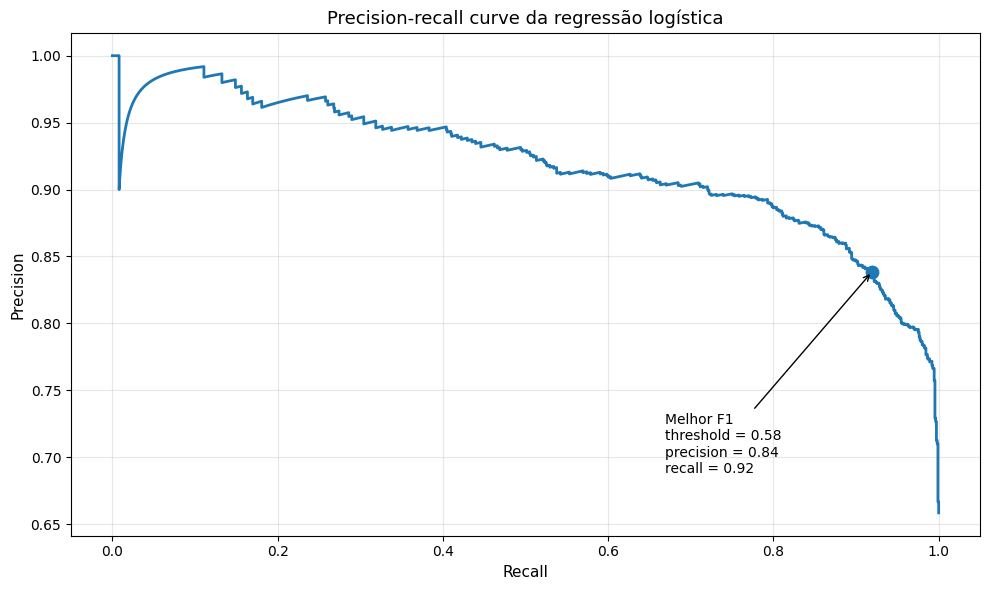

,indicador,valor
0,Threshold de maior F1-score,0.5765
1,Precision nesse threshold,0.8384
2,Recall nesse threshold,0.9192
3,F1-score nesse threshold,0.8769
4,Quantidade de negócios classificados como sucesso,1207.0000



Código executado com sucesso.


In [ ]:
# ==========================================================
# 10. PRECISION-RECALL CURVE E ESCOLHA DO PONTO DE CORTE
# ==========================================================

precisoes_pr, recalls_pr, thresholds_pr = precision_recall_curve(
    y_teste,
    probabilidades_teste_regressao
)

tabela_thresholds_pr = pd.DataFrame({
    "threshold": thresholds_pr,
    "precision": precisoes_pr[:-1],
    "recall": recalls_pr[:-1],
})

tabela_thresholds_pr["f1_score"] = (
    2
    * tabela_thresholds_pr["precision"]
    * tabela_thresholds_pr["recall"]
    / (tabela_thresholds_pr["precision"] + tabela_thresholds_pr["recall"])
)

tabela_thresholds_pr["f1_score"] = tabela_thresholds_pr["f1_score"].replace([np.inf, -np.inf], np.nan)
tabela_thresholds_pr = tabela_thresholds_pr.dropna(subset=["f1_score"]).reset_index(drop=True)

indice_melhor_f1 = tabela_thresholds_pr["f1_score"].idxmax()
melhor_linha_f1 = tabela_thresholds_pr.loc[indice_melhor_f1].copy()

threshold_melhor_f1 = float(melhor_linha_f1["threshold"])

predicoes_teste_melhor_f1 = (probabilidades_teste_regressao >= threshold_melhor_f1).astype(int)

metricas_melhor_threshold = pd.DataFrame({
    "indicador": [
        "Threshold de maior F1-score",
        "Precision nesse threshold",
        "Recall nesse threshold",
        "F1-score nesse threshold",
        "Quantidade de negócios classificados como sucesso",
    ],
    "valor": [
        round(threshold_melhor_f1, 4),
        round(melhor_linha_f1["precision"], 4),
        round(melhor_linha_f1["recall"], 4),
        round(melhor_linha_f1["f1_score"], 4),
        int(predicoes_teste_melhor_f1.sum()),
    ]
})

figura, eixo = plt.subplots(figsize=(10, 6))

eixo.plot(recalls_pr, precisoes_pr, linewidth=2)
eixo.scatter(
    melhor_linha_f1["recall"],
    melhor_linha_f1["precision"],
    s=80,
    marker="o"
)

eixo.set_title("Precision-recall curve da regressão logística")
eixo.set_xlabel("Recall")
eixo.set_ylabel("Precision")
eixo.grid(alpha=0.3)
eixo.set_axisbelow(True)

texto_ponto = (
    f"Melhor F1\n"
    f"threshold = {threshold_melhor_f1:.2f}\n"
    f"precision = {melhor_linha_f1['precision']:.2f}\n"
    f"recall = {melhor_linha_f1['recall']:.2f}"
)

eixo.annotate(
    texto_ponto,
    xy=(melhor_linha_f1["recall"], melhor_linha_f1["precision"]),
    xytext=(melhor_linha_f1["recall"] - 0.25, melhor_linha_f1["precision"] - 0.15),
    arrowprops=dict(arrowstyle="->", lw=1),
    fontsize=10
)

plt.tight_layout()
plt.show()

display(metricas_melhor_threshold)

print("\nCódigo executado com sucesso.")

A precision-recall curve mostra que o melhor equilíbrio entre precisão e recall não está no corte padrão de 0,5, mas em um threshold de **0,5765**. Esse ajuste é importante porque torna a régua de classificação mais aderente ao comportamento real do modelo e mais útil para a priorização comercial.

Nesse ponto de corte, a **precisão** fica em **83,84%**. Isso significa que, entre os negócios classificados como promissores, pouco mais de 8 em cada 10 realmente avançam para R2. O **recall** fica em **91,92%**, indicando que o modelo continua capturando a maior parte dos casos que de fato tiveram sucesso, deixando de fora apenas uma parcela pequena.

O **F1-score** de **87,69%** confirma que esse threshold entrega um equilíbrio forte entre acertar os casos promissores e não perder muitos sucessos reais. Com essa régua, **1.207 negócios** do conjunto de teste passam a ser classificados como sucesso, formando uma carteira mais concentrada do que a obtida com um critério mais frouxo, mas ainda ampla o suficiente para manter alta cobertura dos casos que realmente avançam.

**Leitura prática para o comercial:** esse ponto de corte cria uma seleção mais qualificada de negócios em R1. Em vez de tratar uma parcela muito ampla da carteira como promissora, a classificação passa a concentrar melhor os casos com perfil mais próximo dos que realmente chegam a R2, sem perder capacidade de captura. Isso favorece uma priorização mais útil, com ganho de foco sem sacrificar demais o alcance.

## 11. Comparação entre o corte padrão e o corte orientado pela precision-recall curve

Será comparado o desempenho da regressão no corte padrão de 0,5 e no corte de maior F1-score para mostrar como a mudança de limiar altera o equilíbrio entre acerto, cobertura e tamanho da carteira priorizada.

In [ ]:
# ==========================================================
# 11. COMPARAÇÃO ENTRE O CORTE PADRÃO E O CORTE ORIENTADO
#     PELA PRECISION-RECALL CURVE
# ==========================================================

predicoes_teste_regressao_05 = (probabilidades_teste_regressao >= 0.50).astype(int)
predicoes_teste_regressao_f1 = (probabilidades_teste_regressao >= threshold_melhor_f1).astype(int)

comparacao_cortes_regressao = pd.DataFrame({
    "corte": ["0.50", f"{threshold_melhor_f1:.4f}"],
    "precision": [
        round(precision_score(y_teste, predicoes_teste_regressao_05, zero_division=0), 4),
        round(precision_score(y_teste, predicoes_teste_regressao_f1, zero_division=0), 4),
    ],
    "recall": [
        round(recall_score(y_teste, predicoes_teste_regressao_05, zero_division=0), 4),
        round(recall_score(y_teste, predicoes_teste_regressao_f1, zero_division=0), 4),
    ],
    "f1_score": [
        round(f1_score(y_teste, predicoes_teste_regressao_05, zero_division=0), 4),
        round(f1_score(y_teste, predicoes_teste_regressao_f1, zero_division=0), 4),
    ],
    "quantidade_classificados_como_sucesso": [
        int(predicoes_teste_regressao_05.sum()),
        int(predicoes_teste_regressao_f1.sum()),
    ],
})

display(comparacao_cortes_regressao)

print("\nCódigo executado com sucesso.")

,corte,precision,recall,f1_score,quantidade_classificados_como_sucesso
0,0.50,0.8055,0.9519,0.8726,1301
1,0.5765,0.8384,0.9192,0.8769,1207



Código executado com sucesso.


A comparação mostra que o corte orientado pela precision-recall curve não produz uma mudança drástica em relação ao corte padrão de 0,50. O ganho em F1-score é pequeno, saindo de 87,26% para 87,69%, o que indica que o corte padrão já entregava um desempenho bastante forte.

A principal diferença aparece no perfil da seleção. Com o corte de 0,5765, a **precisão** sobe de 80,55% para 83,84%, o que significa uma carteira um pouco mais qualificada. Em contrapartida, o **recall** cai de 95,19% para 91,92%, indicando uma pequena perda de cobertura sobre os casos que realmente avançam para R2. Ao mesmo tempo, a quantidade de negócios classificados como sucesso cai de 1.301 para 1.207, deixando a carteira priorizada mais enxuta.

**Leitura prática para o comercial:** não houve uma virada de desempenho, mas sim uma troca entre amplitude e seletividade. O corte de 0,50 mantém uma cobertura maior dos sucessos reais, enquanto o corte de 0,5765 entrega uma seleção um pouco mais precisa. Isso sugere que a escolha entre os dois limiares deve ser guiada menos por diferença técnica e mais pelo tipo de uso que se deseja fazer da carteira priorizada.

## 12. Construção de faixas de propensão para priorização comercial

As probabilidades estimadas pela regressão serão organizadas em três faixas de propensão, usando os intervalos de até 40%, de 40% a 70% e acima de 70%, para facilitar a leitura do comercial e separar os negócios com menor, média e maior chance de avanço para R2.

In [ ]:
# ==========================================================
# 12. CONSTRUÇÃO DE FAIXAS DE PROPENSÃO PARA PRIORIZAÇÃO
#     COMERCIAL
# ==========================================================

base_resultados_teste = X_teste.copy()
base_resultados_teste["sucesso_r1_r2_real"] = y_teste.values
base_resultados_teste["probabilidade_sucesso_r1_r2"] = probabilidades_teste_regressao

base_resultados_teste["faixa_propensao_r1_r2"] = pd.cut(
    base_resultados_teste["probabilidade_sucesso_r1_r2"],
    bins=[-0.01, 0.40, 0.70, 1.00],
    labels=[
        "Baixa propensão",
        "Média propensão",
        "Alta propensão",
    ]
)

resumo_faixas_propensao = (
    base_resultados_teste
    .groupby("faixa_propensao_r1_r2", observed=False)
    .agg(
        quantidade_negocios=("sucesso_r1_r2_real", "size"),
        quantidade_sucessos=("sucesso_r1_r2_real", "sum"),
        probabilidade_media=("probabilidade_sucesso_r1_r2", "mean"),
    )
    .reset_index()
)

resumo_faixas_propensao["taxa_real_sucesso"] = (
    resumo_faixas_propensao["quantidade_sucessos"]
    / resumo_faixas_propensao["quantidade_negocios"]
    * 100
).round(2)

resumo_faixas_propensao["probabilidade_media"] = (
    resumo_faixas_propensao["probabilidade_media"] * 100
).round(2)

display(resumo_faixas_propensao)

print("\nCódigo executado com sucesso.")

,faixa_propensao_r1_r2,quantidade_negocios,quantidade_sucessos,probabilidade_media,taxa_real_sucesso
0,Baixa propensão,309,25,10.89,8.09
1,Média propensão,373,197,58.74,52.82
2,Alta propensão,990,879,86.12,88.79



Código executado com sucesso.


As faixas de propensão foram construídas a partir das probabilidades estimadas pela **regressão logística**, e não da baseline simples. A baseline foi usada apenas como referência de comparação. Quem efetivamente gerou a classificação dos negócios em baixa, média e alta propensão foi o modelo estatístico, ao atribuir uma probabilidade individual de avanço para cada caso.

Depois disso, essas probabilidades foram organizadas em três faixas para facilitar o uso comercial da análise: até **40%** de chance estimada de avanço para R2 foi tratado como **baixa propensão**, de **40% a 70%** como **média propensão** e acima de **70%** como **alta propensão**. A intenção aqui não é transformar a carteira em uma decisão rígida de “vai avançar” ou “não vai avançar”, mas criar uma régua prática de priorização.

O resultado mostra que essa régua separa bem os perfis da carteira. Entre os negócios classificados como **baixa propensão**, a taxa real de sucesso foi de apenas **8,09%**. Na **média propensão**, a taxa real de sucesso subiu para **52,82%**. Já na faixa de **alta propensão**, a taxa real chegou a **88,79%**. Em outras palavras, os grupos formados pelo modelo passaram a refletir comportamentos muito diferentes de avanço para R2.

Para o comercial, a utilidade prática fica mais clara assim:
- a faixa de **alta propensão** reúne os casos mais promissores e tende a ser a melhor candidata para foco prioritário;
- a faixa de **média propensão** concentra casos intermediários, que podem avançar, mas pedem acompanhamento mais seletivo e leitura de contexto;
- a faixa de **baixa propensão** reúne negócios com chance reduzida de chegar a R2, o que sugere menor prioridade imediata ou necessidade de abordagem diferente.

A principal mensagem é que o modelo deixou de tratar toda a carteira de R1 como homogênea. Em vez disso, passou a organizar os negócios em grupos com níveis bem diferentes de chance de avanço. Isso dá ao comercial uma forma mais objetiva de distribuir esforço, concentrar atenção onde a probabilidade de retorno é maior e evitar o mesmo nível de dedicação para casos com perspectivas muito distintas.

## 13. Leitura consolidada da regressão para uso comercial

Será consolidada uma síntese da regressão logística para traduzir o ganho do modelo em uma leitura mais direta sobre priorização comercial, diferenciação da carteira e utilidade prática das probabilidades estimadas.

In [ ]:
# ==========================================================
# 13. LEITURA CONSOLIDADA DA REGRESSÃO PARA USO COMERCIAL
# ==========================================================

quantidade_alta_propensao = int(
    (base_resultados_teste["faixa_propensao_r1_r2"] == "Alta propensão").sum()
)
quantidade_media_propensao = int(
    (base_resultados_teste["faixa_propensao_r1_r2"] == "Média propensão").sum()
)
quantidade_baixa_propensao = int(
    (base_resultados_teste["faixa_propensao_r1_r2"] == "Baixa propensão").sum()
)

taxa_sucesso_alta_propensao = float(
    resumo_faixas_propensao.loc[
        resumo_faixas_propensao["faixa_propensao_r1_r2"] == "Alta propensão",
        "taxa_real_sucesso"
    ].iloc[0]
)

taxa_sucesso_media_propensao = float(
    resumo_faixas_propensao.loc[
        resumo_faixas_propensao["faixa_propensao_r1_r2"] == "Média propensão",
        "taxa_real_sucesso"
    ].iloc[0]
)

taxa_sucesso_baixa_propensao = float(
    resumo_faixas_propensao.loc[
        resumo_faixas_propensao["faixa_propensao_r1_r2"] == "Baixa propensão",
        "taxa_real_sucesso"
    ].iloc[0]
)

ganho_absoluto_average_precision = round(0.9196 - 0.6585, 4)
ganho_relativo_average_precision = round(((0.9196 - 0.6585) / 0.6585) * 100, 2)

leitura_consolidada_regressao = pd.DataFrame({
    "mensagem_chave": [
        "A regressão supera a baseline simples na separação da carteira.",
        "A faixa de alta propensão concentra os casos mais promissores.",
        "A faixa de baixa propensão reúne casos com baixa chance real de avanço.",
        "A segmentação passa a apoiar priorização mais objetiva da carteira.",
    ],
    "evidencia_principal": [
        f"Average precision: 65,85% → 91,96% (ganho de {ganho_relativo_average_precision:.2f}% relativo).".replace(".", ","),
        f"{quantidade_alta_propensao} negócios em alta propensão com taxa real de sucesso de {taxa_sucesso_alta_propensao:.2f}%.".replace(".", ","),
        f"{quantidade_baixa_propensao} negócios em baixa propensão com taxa real de sucesso de {taxa_sucesso_baixa_propensao:.2f}%.".replace(".", ","),
        "A carteira deixa de ser tratada como homogênea e passa a ser organizada por chance estimada de avanço.",
    ],
})

for _, linha in leitura_consolidada_regressao.iterrows():
    print("=" * 95)
    print(f"MENSAGEM-CHAVE: {linha['mensagem_chave']}")
    print(f"Evidência principal: {linha['evidencia_principal']}")
    print()

print("Código executado com sucesso.")

MENSAGEM-CHAVE: A regressão supera a baseline simples na separação da carteira.
Evidência principal: Average precision: 65,85% → 91,96% (ganho de 39,65% relativo),

MENSAGEM-CHAVE: A faixa de alta propensão concentra os casos mais promissores.
Evidência principal: 990 negócios em alta propensão com taxa real de sucesso de 88,79%,

MENSAGEM-CHAVE: A faixa de baixa propensão reúne casos com baixa chance real de avanço.
Evidência principal: 309 negócios em baixa propensão com taxa real de sucesso de 8,09%,

MENSAGEM-CHAVE: A segmentação passa a apoiar priorização mais objetiva da carteira.
Evidência principal: A carteira deixa de ser tratada como homogênea e passa a ser organizada por chance estimada de avanço.

Código executado com sucesso.


A regressão logística já entrega uma leitura suficientemente forte para uso comercial, porque não apenas melhora o desempenho em relação à referência simples, mas também transforma essa melhora em uma organização mais útil da carteira. O ponto central não está só no ganho de métrica, mas no fato de que os negócios passam a ser distinguidos por probabilidade estimada de avanço, e essa diferenciação mostrou aderência ao que realmente aconteceu.

Para o comercial, a mensagem prática é clara: a carteira de R1 deixa de ser uma fila única e passa a poder ser lida em camadas de prioridade. Os casos de alta propensão concentram uma chance muito superior de chegar a R2, enquanto os de baixa propensão mostram perspectiva bem mais reduzida. Isso cria uma base mais objetiva para decidir onde concentrar esforço, onde acompanhar com seletividade e onde uma abordagem diferente pode ser mais adequada.